# DATA425 Lab 6: CNNs, Training, Transfer Learning, and Fine-Tuning

In this lab, we use small handwritten digit images to make the main CNN ideas concrete. The images are tiny, but the ideas are the same ones used for much larger image datasets.

By the end, you will have worked through:

1. how images are stored as tensors rather than just flattened lists of numbers,
2. how convolution filters create feature maps,
3. how stride, padding, pooling, output sizes, and parameter counts fit together,
4. how to train a CNN and read its diagnostics,
5. how to reuse a learned backbone for a related task,
6. how fine-tuning adapts a model when the target data looks slightly different,
7. how residual connections make it easier for deep networks to preserve useful representations,
8. how one shared backbone can support multiple prediction heads.

The goal is not to memorize the code. The goal is to connect each line of code to the mental picture from the lectures: images go in, local filters detect patterns, deeper layers combine those patterns, and the final head turns the learned representation into a prediction.

## How this lab maps to the lecture material

This notebook follows the same storyline as the CNN and transfer-learning lectures. Use the table as a guide when you want to connect a code section back to a lecture idea.

| Lecture idea | What you will see in this lab |
|---|---|
| Images as matrices or tensors | `load_digits` images are reshaped into `N × C × H × W` tensors |
| Why flattening is limited | a parameter-count comparison between fully connected and convolutional layers |
| Local image filters | manual 2D convolution with edge-detecting filters |
| 3D convolution | `Conv2d` filters span height, width, and input channels |
| Stride, padding, and pooling | output-size calculations and a max-pooling example |
| CNNs for classification | a small CNN trained end-to-end on handwritten digits |
| Model diagnostics | train/validation curves, a test-set report, and a confusion matrix |
| Backbone and head terminology | a CNN split into a reusable feature extractor and a task-specific classifier |
| Transfer learning | a frozen backbone with a new parity-classification head |
| Fine-tuning | adapting a clean-image model to noisy images |
| Residual connections | a small block that can learn to return its input unchanged |
| Multitask learning | one shared embedding with two prediction heads |

When you run the notebook, pause after each section and ask: which part of the model is learning a representation, and which part is using that representation for a specific task?

In [1]:
# Core setup
import os
import random
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader, Subset
import torch.nn.functional as F

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


def set_seed(seed: int = 425):
    # Make the demonstration reproducible.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.set_num_threads(2)

set_seed(425)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## 1. Load an image dataset and treat images as tensors

A grayscale image is a grid of pixel values. An RGB image is a stack of three grids: red, green, and blue. Deep-learning libraries keep that structure instead of immediately flattening everything into one long vector.

PyTorch expects image batches in this shape:

$$
N \times C \times H \times W,
$$

where:

- `N` is the number of images in the batch,
- `C` is the number of channels,
- `H` is image height,
- `W` is image width.

The `digits` dataset contains 8×8 grayscale images, so each image has one channel and 64 pixels. The original pixel values are in `[0, 16]`. We scale them to `[0, 1]` because neural networks usually train more smoothly when inputs have a small, consistent range.

After running the next cells, look carefully at the printed tensor shapes. Shape checking is one of the most useful debugging habits in deep learning.

In [2]:
digits = load_digits()
X = digits.images.astype("float32") / 16.0     # shape: (N, 8, 8)
y = digits.target.astype("int64")              # labels: 0, ..., 9
X = X[:, None, :, :]                           # add channel dimension: (N, 1, 8, 8)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=425
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=425
)

print("Full tensor shape:", X.shape, "= (images, channels, height, width)")
print("Train/val/test:", X_train.shape, X_val.shape, X_test.shape)
print("Class labels:", np.unique(y))
print("Pixel range after scaling:", X.min(), "to", X.max())

Full tensor shape: (1797, 1, 8, 8) = (images, channels, height, width)
Train/val/test: (1257, 1, 8, 8) (270, 1, 8, 8) (270, 1, 8, 8)
Class labels: [0 1 2 3 4 5 6 7 8 9]
Pixel range after scaling: 0.0 to 1.0


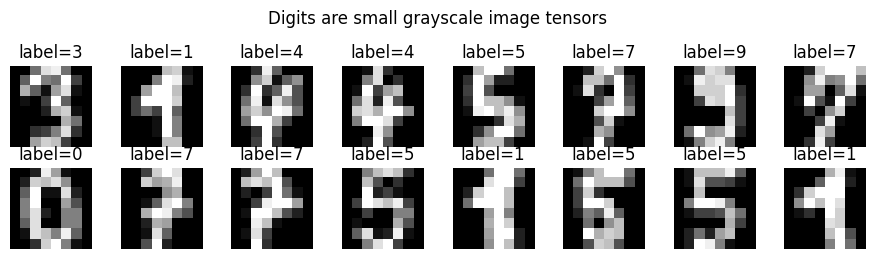

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(9, 2.6))
for ax, img, label in zip(axes.ravel(), X_train[:16, 0], y_train[:16]):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"label={label}")
    ax.axis("off")
plt.suptitle("Digits are small grayscale image tensors")
plt.tight_layout()
plt.show()

## 2. Why not just flatten images?

A fully connected layer treats every input value as separate from every other input value. If we flatten an image, pixels that used to be neighbours in the image grid are no longer explicitly treated as neighbours.

That causes two problems:

1. **Too many parameters:** every input pixel can connect to every hidden unit.
2. **Lost spatial structure:** the model is not naturally told that nearby pixels form edges, corners, textures, and shapes.

A convolutional layer solves both problems by learning a small filter and reusing that same filter at every spatial location. This reuse is called **weight sharing**. It is one of the main reasons CNNs are practical for images.

The next cell compares parameter counts. Notice that the difference becomes much larger as image size grows.

In [4]:
def dense_params(n_inputs, n_outputs):
    return n_inputs * n_outputs + n_outputs

def conv_params(filter_size, in_channels, out_channels):
    return filter_size * filter_size * in_channels * out_channels + out_channels

comparison = pd.DataFrame([
    {
        "scenario": "8×8 grayscale digits → 32 hidden units, fully connected",
        "parameters": dense_params(8 * 8, 32),
    },
    {
        "scenario": "8×8 grayscale digits → 32 filters of size 3×3",
        "parameters": conv_params(3, 1, 32),
    },
    {
        "scenario": "224×224 RGB image → 1,000 hidden units, fully connected",
        "parameters": dense_params(224 * 224 * 3, 1000),
    },
    {
        "scenario": "224×224 RGB image → 64 filters of size 3×3",
        "parameters": conv_params(3, 3, 64),
    },
])
comparison["parameters"] = comparison["parameters"].map(lambda v: f"{v:,}")
display(comparison)
print("A convolutional filter has few parameters because it is reused across all image locations.")

,scenario,parameters
0,"8×8 grayscale digits → 32 hidden units, fully ...","2,080"
1,8×8 grayscale digits → 32 filters of size 3×3,320
2,"224×224 RGB image → 1,000 hidden units, fully ...","150,529,000"
3,224×224 RGB image → 64 filters of size 3×3,"1,792"


A convolutional filter has few parameters because it is reused across all image locations.


## 3. Manual 2D convolution: filters create feature maps

A convolution asks a simple question at each location in the image: how well does this small patch match the filter?

For one filter and one image patch, the calculation is:

$$
\text{activation} = \sum_{u,v} F_{u,v} X_{i+u,j+v} + b.
$$

Here:

- $F$ is the filter, also called a kernel,
- $X$ is the image,
- $(i,j)$ is the current spatial location,
- $b$ is a bias term.

The filter slides over the image and produces a new grid of activations called a **feature map**. Large values in the feature map mean the filter found the pattern it was looking for.

In the next cell, we manually apply edge filters. This is a small version of what CNN layers learn automatically during training.

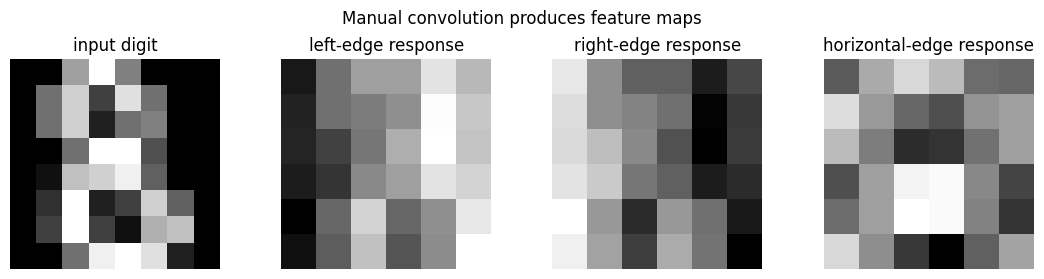

Input shape: (8, 8)
Feature-map shape with a 3×3 filter, stride 1, no padding: (6, 6)


In [5]:
def conv2d_valid(image, kernel, stride=1, padding=0):
    # A small, explicit 2D convolution/cross-correlation for teaching.
    if padding > 0:
        image = np.pad(image, padding, mode="constant")
    kH, kW = kernel.shape
    H, W = image.shape
    outH = (H - kH) // stride + 1
    outW = (W - kW) // stride + 1
    out = np.zeros((outH, outW), dtype=np.float32)
    for i in range(outH):
        for j in range(outW):
            patch = image[i * stride:i * stride + kH, j * stride:j * stride + kW]
            out[i, j] = np.sum(patch * kernel)
    return out

# Find a sample with many visible edges.
sample_idx = np.where(y_train == 8)[0][0]
sample = X_train[sample_idx, 0]

left_edge = np.array([[ 1, 0, -1],
                      [ 1, 0, -1],
                      [ 1, 0, -1]], dtype=np.float32)
right_edge = -left_edge
horizontal_edge = np.array([[ 1,  1,  1],
                            [ 0,  0,  0],
                            [-1, -1, -1]], dtype=np.float32)

feature_maps = {
    "input digit": sample,
    "left-edge response": conv2d_valid(sample, left_edge),
    "right-edge response": conv2d_valid(sample, right_edge),
    "horizontal-edge response": conv2d_valid(sample, horizontal_edge),
}

fig, axes = plt.subplots(1, 4, figsize=(11, 2.8))
for ax, (title, image) in zip(axes, feature_maps.items()):
    ax.imshow(image, cmap="gray")
    ax.set_title(title)
    ax.axis("off")
plt.suptitle("Manual convolution produces feature maps")
plt.tight_layout()
plt.show()

print("Input shape:", sample.shape)
print("Feature-map shape with a 3×3 filter, stride 1, no padding:", feature_maps["left-edge response"].shape)

## 4. Stride, padding, output sizes, and parameter counts

Convolution changes the spatial size of the data. For a square input with spatial size `N`, filter size `F`, stride `S`, and padding `P`, the output spatial size is:

$$
\frac{N - F + 2P}{S} + 1.
$$

The result needs to be an integer. If the filter does not land cleanly on the image grid, the configuration is usually not valid.

The meaning of each hyperparameter is:

- **filter size `F`:** how large each local patch is,
- **stride `S`:** how far the filter moves each step,
- **padding `P`:** how many zeros are added around the image border.

The parameter count is separate from the output size. A convolution can produce many spatial activations while still using only a small number of learned weights because the same filter is reused across the image.

In [6]:
def conv_output_size(N, F, S=1, P=0):
    numerator = N - F + 2 * P
    if numerator % S != 0:
        return "does not fit cleanly"
    return numerator // S + 1

examples = pd.DataFrame([
    {"N": 7, "F": 3, "S": 1, "P": 0, "output": conv_output_size(7, 3, 1, 0)},
    {"N": 7, "F": 3, "S": 2, "P": 0, "output": conv_output_size(7, 3, 2, 0)},
    {"N": 7, "F": 3, "S": 3, "P": 0, "output": conv_output_size(7, 3, 3, 0)},
    {"N": 7, "F": 3, "S": 1, "P": 1, "output": conv_output_size(7, 3, 1, 1)},
    {"N": 32, "F": 5, "S": 1, "P": 2, "output": conv_output_size(32, 5, 1, 2)},
])
display(examples)

print("Parameters for K filters of size F×F×D_in:")
print("F × F × D_in × K weights + K biases")
print("Example: 64 filters, each 3×3×32:", conv_params(3, 32, 64), "learned parameters")

,N,F,S,P,output
0,7,3,1,0,5
1,7,3,2,0,3
2,7,3,3,0,does not fit cleanly
3,7,3,1,1,7
4,32,5,1,2,32


Parameters for K filters of size F×F×D_in:
F × F × D_in × K weights + K biases
Example: 64 filters, each 3×3×32: 18496 learned parameters


## 5. A real 3D convolution layer

Even when the image is visually 2D, the convolutional filter has depth. For grayscale images, the depth is 1 channel. For RGB images, the depth is 3 channels. For later CNN layers, the depth is the number of feature maps from the previous layer.

A PyTorch `Conv2d` weight tensor has shape:

$$
K \times C_{in} \times F \times F,
$$

where `K` is the number of filters. Each filter produces one output feature map, so `K` filters produce `K` output channels.

The next cell prints the input shape, output shape, weight shape, and number of learned parameters. Use these printed shapes to connect the formula to the actual PyTorch layer.

In [7]:
conv = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1)
x_example = torch.tensor(X_train[:4])
with torch.no_grad():
    y_example = conv(x_example)

print("Input batch shape: ", tuple(x_example.shape), "= (N, C, H, W)")
print("Conv output shape:", tuple(y_example.shape), "= (N, K, H_out, W_out)")
print("Conv weight shape:", tuple(conv.weight.shape), "= (K, C_in, F, F)")
print("Learned parameters:", sum(p.numel() for p in conv.parameters()))

Input batch shape:  (4, 1, 8, 8) = (N, C, H, W)
Conv output shape: (4, 6, 8, 8) = (N, K, H_out, W_out)
Conv weight shape: (6, 1, 3, 3) = (K, C_in, F, F)
Learned parameters: 60


## 6. Pooling reduces spatial size without adding learned parameters

Pooling is a downsampling step. It is applied independently to each channel and usually makes feature maps smaller.

In max pooling, each local window is replaced by its largest value. This keeps the strongest response in that small region. For example, if an edge detector fires strongly anywhere inside a 2×2 window, max pooling keeps that strong response and drops the weaker ones.

Pooling has hyperparameters, such as kernel size and stride, but it does not learn weights. The next cell reproduces the lecture-style 2×2 max-pooling example so you can see the operation directly on a small matrix.

In [8]:
pool_input = torch.tensor([[[[1, 1, 2, 4],
                             [5, 6, 7, 8],
                             [3, 2, 1, 0],
                             [1, 2, 3, 4]]]], dtype=torch.float32)
maxpool = nn.MaxPool2d(kernel_size=2, stride=2)
pool_output = maxpool(pool_input)

print("Input matrix:")
print(pool_input[0, 0].numpy().astype(int))
print("\nMaxPool2d(kernel_size=2, stride=2) output:")
print(pool_output[0, 0].numpy().astype(int))
print("\nTrainable pooling parameters:", sum(p.numel() for p in maxpool.parameters()))

Input matrix:
[[1 1 2 4]
 [5 6 7 8]
 [3 2 1 0]
 [1 2 3 4]]

MaxPool2d(kernel_size=2, stride=2) output:
[[6 8]
 [3 4]]

Trainable pooling parameters: 0


## 7. Build a CNN as backbone plus head

A useful way to think about image models is:

$$
\text{image} \rightarrow \text{backbone} \rightarrow \text{embedding} \rightarrow \text{head} \rightarrow \text{prediction}.
$$

The **backbone** learns general image features. In this lab, those features include patterns useful for recognizing handwritten digits. The **embedding** is a compact vector representation of the image. The **head** maps that representation to the labels for a specific task.

We build the model in this structure on purpose. Later, we will reuse the backbone and embedding for a different task, which is the core idea of transfer learning.

When you run the shape-tracing code, follow how the tensor changes after each layer. This is the easiest way to understand what the architecture is doing.

In [9]:
def make_loader(X_array, y_array, batch_size=64, shuffle=True):
    X_tensor = torch.tensor(X_array, dtype=torch.float32)
    y_tensor = torch.tensor(y_array, dtype=torch.long)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, y_train, batch_size=64, shuffle=True)
val_loader = make_loader(X_val, y_val, batch_size=128, shuffle=False)
test_loader = make_loader(X_test, y_test, batch_size=128, shuffle=False)

class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, embedding_dim=32):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 8×8 -> 4×4
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                  # 4×4 -> 2×2
            nn.Flatten(),
        )
        self.embedding = nn.Sequential(
            nn.Linear(32 * 2 * 2, embedding_dim),
            nn.ReLU(),
        )
        self.head = nn.Linear(embedding_dim, num_classes)

    def features(self, x):
        return self.embedding(self.backbone(x))

    def forward(self, x):
        z = self.features(x)
        return self.head(z)

model = SmallCNN(num_classes=10).to(device)
print(model)
print("Total trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# Show layer-by-layer tensor shapes for one batch.
with torch.no_grad():
    x_batch, _ = next(iter(train_loader))
    x_batch = x_batch[:8].to(device)
    out = x_batch
    print("\nShape tracing:")
    print("input:", tuple(out.shape))
    for i, layer in enumerate(model.backbone):
        out = layer(out)
        print(f"backbone[{i}] {layer.__class__.__name__:>12}:", tuple(out.shape))
    out = model.embedding(out)
    print("embedding:", tuple(out.shape))
    out = model.head(out)
    print("head logits:", tuple(out.shape))

SmallCNN(
  (backbone): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (embedding): Sequential(
    (0): Linear(in_features=128, out_features=32, bias=True)
    (1): ReLU()
  )
  (head): Linear(in_features=32, out_features=10, bias=True)
)
Total trainable parameters: 9258

Shape tracing:
input: (8, 1, 8, 8)
backbone[0]       Conv2d: (8, 16, 8, 8)
backbone[1]         ReLU: (8, 16, 8, 8)
backbone[2]    MaxPool2d: (8, 16, 4, 4)
backbone[3]       Conv2d: (8, 32, 4, 4)
backbone[4]         ReLU: (8, 32, 4, 4)
backbone[5]    MaxPool2d: (8, 32, 2, 2)
backbone[6]      Flatten: (8, 128)
embedding: (8, 32)
head logits: (8, 10)


## 8. Train the CNN

Training follows the standard supervised-learning workflow:

1. train the model only on the training set,
2. monitor validation performance while choosing or checking the model,
3. evaluate once on the held-out test set at the end.

The model outputs **logits**, which are raw class scores. Cross-entropy loss compares those scores with the true class label. Internally, cross-entropy rewards the model for placing high probability on the correct class and penalizes it for putting probability on the wrong classes.

The train/validation curves help you diagnose what is happening:

- if both train and validation performance are poor, the model may be underfitting,
- if training performance improves but validation performance gets worse, the model may be overfitting,
- if both improve together, training is probably moving in a useful direction.

The final test set is used only after training so that it remains a fair estimate of performance on unseen data.

In [10]:
def evaluate_classifier(model, loader, loss_fn=nn.CrossEntropyLoss()):
    model.eval()
    total_loss, total_correct, total_examples = 0.0, 0, 0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = loss_fn(logits, yb)
            preds = logits.argmax(dim=1)
            total_loss += loss.item() * xb.size(0)
            total_correct += (preds == yb).sum().item()
            total_examples += xb.size(0)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(yb.cpu().numpy())
    return {
        "loss": total_loss / total_examples,
        "accuracy": total_correct / total_examples,
        "preds": np.concatenate(all_preds),
        "targets": np.concatenate(all_targets),
    }


def train_classifier(model, train_loader, val_loader, epochs=15, lr=1e-2, weight_decay=0.0, clip_norm=None):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = []
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, n = 0.0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            if clip_norm is not None:
                nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            optimizer.step()
            running_loss += loss.item() * xb.size(0)
            correct += (logits.argmax(dim=1) == yb).sum().item()
            n += xb.size(0)
        val_metrics = evaluate_classifier(model, val_loader, loss_fn)
        history.append({
            "epoch": epoch,
            "train_loss": running_loss / n,
            "train_acc": correct / n,
            "val_loss": val_metrics["loss"],
            "val_acc": val_metrics["accuracy"],
        })
        if epoch in {1, 2, 5, 10, epochs}:
            row = history[-1]
            print(
                f"epoch {epoch:02d} | "
                f"train loss {row['train_loss']:.3f}, acc {row['train_acc']:.3f} | "
                f"val loss {row['val_loss']:.3f}, acc {row['val_acc']:.3f}"
            )
    return pd.DataFrame(history)

history = train_classifier(model, train_loader, val_loader, epochs=15, lr=1e-2)
print("\nFinal validation accuracy:", f"{history.val_acc.iloc[-1]:.3f}")

epoch 01 | train loss 2.237, acc 0.185 | val loss 1.883, acc 0.400
epoch 02 | train loss 1.242, acc 0.597 | val loss 0.795, acc 0.711
epoch 05 | train loss 0.132, acc 0.959 | val loss 0.212, acc 0.911
epoch 10 | train loss 0.030, acc 0.994 | val loss 0.151, acc 0.963
epoch 15 | train loss 0.010, acc 0.997 | val loss 0.070, acc 0.978

Final validation accuracy: 0.978


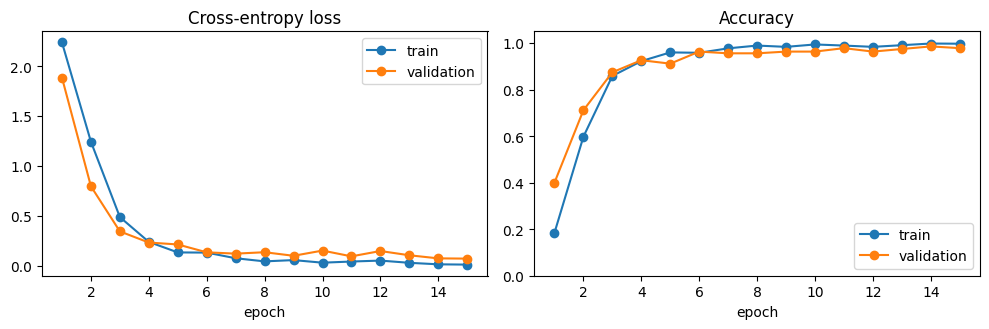

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
ax[0].plot(history["epoch"], history["val_loss"], marker="o", label="validation")
ax[0].set_title("Cross-entropy loss")
ax[0].set_xlabel("epoch")
ax[0].legend()

ax[1].plot(history["epoch"], history["train_acc"], marker="o", label="train")
ax[1].plot(history["epoch"], history["val_acc"], marker="o", label="validation")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].set_ylim(0, 1.05)
ax[1].legend()
plt.tight_layout()
plt.show()

Test accuracy: 0.978

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       1.00      1.00      1.00        27
           2       1.00      1.00      1.00        27
           3       0.96      1.00      0.98        27
           4       0.96      0.93      0.94        27
           5       1.00      0.96      0.98        28
           6       1.00      1.00      1.00        27
           7       1.00      1.00      1.00        27
           8       0.93      1.00      0.96        26
           9       0.92      0.89      0.91        27

    accuracy                           0.98       270
   macro avg       0.98      0.98      0.98       270
weighted avg       0.98      0.98      0.98       270



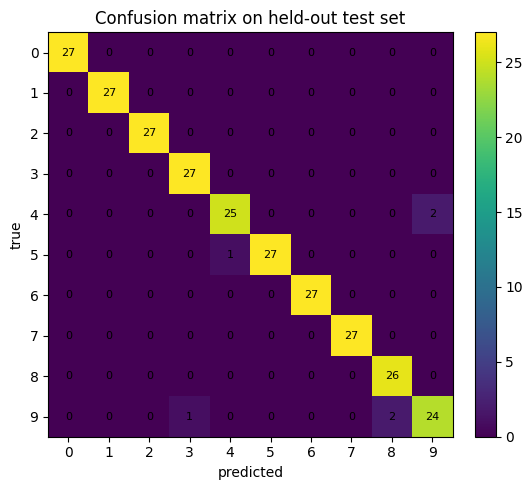

In [12]:
test_metrics = evaluate_classifier(model, test_loader)
print(f"Test accuracy: {test_metrics['accuracy']:.3f}")
print("\nClassification report:")
print(classification_report(test_metrics["targets"], test_metrics["preds"]))

cm = confusion_matrix(test_metrics["targets"], test_metrics["preds"])
fig, ax = plt.subplots(figsize=(5.5, 5))
im = ax.imshow(cm)
ax.set_title("Confusion matrix on held-out test set")
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_xticks(range(10))
ax.set_yticks(range(10))
for i in range(10):
    for j in range(10):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

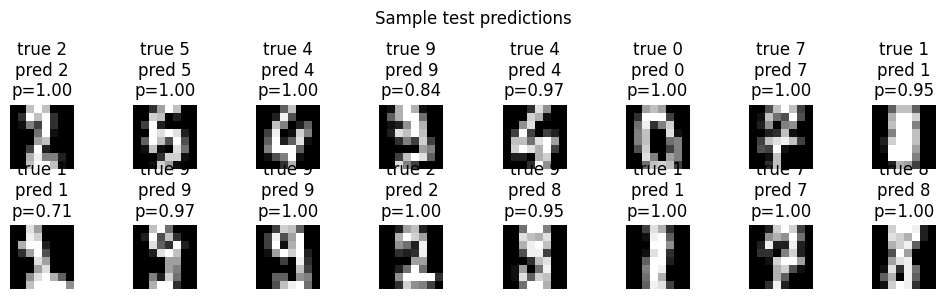

In [13]:
# Visual check: do the outputs look like the intended outcome?
model.eval()
with torch.no_grad():
    xb, yb = next(iter(test_loader))
    logits = model(xb.to(device))
    probs = logits.softmax(dim=1).cpu()
    preds = probs.argmax(dim=1).numpy()

fig, axes = plt.subplots(2, 8, figsize=(10, 3))
for ax, img, true_label, pred_label, prob in zip(axes.ravel(), xb[:16, 0], yb[:16], preds[:16], probs[:16].max(dim=1).values):
    ax.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"true {int(true_label)}\npred {pred_label}\np={float(prob):.2f}")
    ax.axis("off")
plt.suptitle("Sample test predictions")
plt.tight_layout()
plt.show()

## 9. Transfer learning: freeze the backbone and replace the head

Transfer learning reuses a representation learned on one task for a related task.

Here the source task is:

$$
\text{digit image} \rightarrow \text{digit label } 0,\ldots,9.
$$

The target task is:

$$
\text{digit image} \rightarrow \text{parity label: even or odd}.
$$

The input domain is still handwritten digit images, but the label definition changes. Since the backbone has already learned useful digit features, we freeze the backbone and embedding, replace the classification head, and train only the new head on a small target-task dataset.

Freezing means `requires_grad = False`. Frozen weights still participate in the forward pass, but they are not updated during backpropagation.

In [14]:
# Target labels for the new task: 0 = even, 1 = odd
parity_train = (y_train % 2).astype("int64")
parity_val = (y_val % 2).astype("int64")
parity_test = (y_test % 2).astype("int64")

# Use a small target-labeled subset to make the transfer-learning benefit visible.
rng = np.random.default_rng(425)
small_indices = []
for cls in [0, 1]:
    idx = np.where(parity_train == cls)[0]
    small_indices.extend(rng.choice(idx, size=35, replace=False))
small_indices = np.array(small_indices)
rng.shuffle(small_indices)

small_parity_loader = make_loader(X_train[small_indices], parity_train[small_indices], batch_size=32, shuffle=True)
parity_val_loader = make_loader(X_val, parity_val, batch_size=128, shuffle=False)
parity_test_loader = make_loader(X_test, parity_test, batch_size=128, shuffle=False)

print("Small target-task training examples:", len(small_indices))
print("Parity class balance in small set:", np.bincount(parity_train[small_indices]))

Small target-task training examples: 70
Parity class balance in small set: [35 35]


In [15]:
# Transfer model: copy the trained backbone + embedding, then train a fresh head.
transfer_model = SmallCNN(num_classes=2).to(device)
transfer_model.backbone.load_state_dict(model.backbone.state_dict())
transfer_model.embedding.load_state_dict(model.embedding.state_dict())

for p in transfer_model.backbone.parameters():
    p.requires_grad = False
for p in transfer_model.embedding.parameters():
    p.requires_grad = False

scratch_model = SmallCNN(num_classes=2).to(device)

print("Trainable parameters with frozen transferred backbone:", sum(p.numel() for p in transfer_model.parameters() if p.requires_grad))
print("Trainable parameters from scratch:", sum(p.numel() for p in scratch_model.parameters() if p.requires_grad))

transfer_history = train_classifier(transfer_model, small_parity_loader, parity_val_loader, epochs=12, lr=5e-2)
scratch_history = train_classifier(scratch_model, small_parity_loader, parity_val_loader, epochs=12, lr=1e-2)

transfer_test = evaluate_classifier(transfer_model, parity_test_loader)
scratch_test = evaluate_classifier(scratch_model, parity_test_loader)

results = pd.DataFrame([
    {
        "model": "frozen pretrained backbone + new parity head",
        "trainable_parameters": sum(p.numel() for p in transfer_model.parameters() if p.requires_grad),
        "test_accuracy": transfer_test["accuracy"],
    },
    {
        "model": "same architecture trained from scratch on tiny parity set",
        "trainable_parameters": sum(p.numel() for p in scratch_model.parameters() if p.requires_grad),
        "test_accuracy": scratch_test["accuracy"],
    },
])
display(results)
print("The transferred model needs far fewer trainable parameters because the representation is reused.")

Trainable parameters with frozen transferred backbone: 66
Trainable parameters from scratch: 8994
epoch 01 | train loss 1.731, acc 0.543 | val loss 0.133, acc 0.937
epoch 02 | train loss 0.152, acc 0.929 | val loss 0.260, acc 0.896
epoch 05 | train loss 0.133, acc 0.957 | val loss 0.177, acc 0.948
epoch 10 | train loss 0.039, acc 0.986 | val loss 0.128, acc 0.967
epoch 12 | train loss 0.033, acc 0.986 | val loss 0.140, acc 0.959
epoch 01 | train loss 0.709, acc 0.471 | val loss 0.691, acc 0.507
epoch 02 | train loss 0.693, acc 0.500 | val loss 0.689, acc 0.507
epoch 05 | train loss 0.655, acc 0.643 | val loss 0.619, acc 0.774
epoch 10 | train loss 0.290, acc 0.857 | val loss 0.304, acc 0.867
epoch 12 | train loss 0.263, acc 0.914 | val loss 0.469, acc 0.833


,model,trainable_parameters,test_accuracy
0,frozen pretrained backbone + new parity head,66,0.925926
1,same architecture trained from scratch on tiny...,8994,0.848148


The transferred model needs far fewer trainable parameters because the representation is reused.


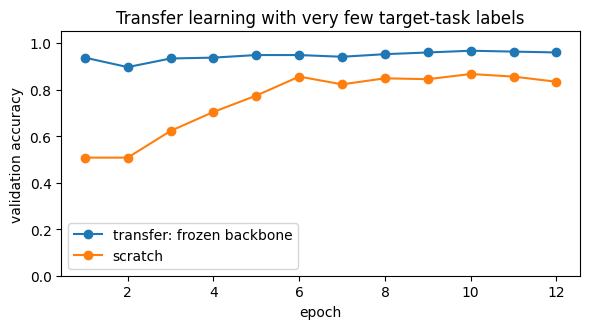

In [16]:
plt.figure(figsize=(6, 3.4))
plt.plot(transfer_history["epoch"], transfer_history["val_acc"], marker="o", label="transfer: frozen backbone")
plt.plot(scratch_history["epoch"], scratch_history["val_acc"], marker="o", label="scratch")
plt.ylim(0, 1.05)
plt.xlabel("epoch")
plt.ylabel("validation accuracy")
plt.title("Transfer learning with very few target-task labels")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Fine-tuning under a domain shift

Fine-tuning is useful when the new data is related to the old data, but not identical.

In this section, the task stays the same: classify digits from `0` to `9`. The domain changes because the images become noisy. We first test the clean-image model on noisy images to see how much the domain shift hurts performance. Then we fine-tune a copy of the model on a small noisy subset.

The main ideas are:

- reuse the pretrained weights as a strong starting point,
- use a smaller learning rate so the model adapts gently,
- update the weights just enough to handle the new domain.

This is different from training from scratch. We are not asking the model to relearn image features from zero; we are asking it to adjust an existing representation.

Clean-trained model accuracy on noisy target domain before fine-tuning: 0.581


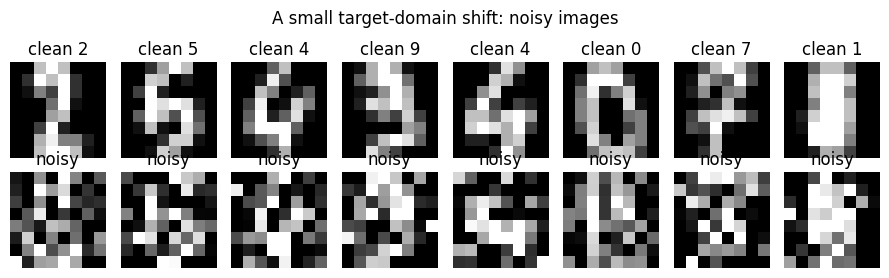

In [17]:
def add_noise(X_array, noise_std=0.45, seed=425):
    rng = np.random.default_rng(seed)
    noisy = X_array + rng.normal(0, noise_std, size=X_array.shape).astype("float32")
    return np.clip(noisy, 0.0, 1.0)

X_train_noisy = add_noise(X_train, noise_std=0.45, seed=1)
X_test_noisy = add_noise(X_test, noise_std=0.45, seed=2)
X_val_noisy = add_noise(X_val, noise_std=0.45, seed=3)

noisy_test_loader = make_loader(X_test_noisy, y_test, batch_size=128, shuffle=False)
noisy_val_loader = make_loader(X_val_noisy, y_val, batch_size=128, shuffle=False)

before_noisy = evaluate_classifier(model, noisy_test_loader)
print(f"Clean-trained model accuracy on noisy target domain before fine-tuning: {before_noisy['accuracy']:.3f}")

fig, axes = plt.subplots(2, 8, figsize=(9, 2.8))
for ax, clean, noisy, label in zip(axes[0], X_test[:8, 0], X_test_noisy[:8, 0], y_test[:8]):
    ax.imshow(clean, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"clean {label}")
    ax.axis("off")
for ax, clean, noisy, label in zip(axes[1], X_test[:8, 0], X_test_noisy[:8, 0], y_test[:8]):
    ax.imshow(noisy, cmap="gray", vmin=0, vmax=1)
    ax.set_title("noisy")
    ax.axis("off")
plt.suptitle("A small target-domain shift: noisy images")
plt.tight_layout()
plt.show()

In [18]:
# Fine-tune a copy on a small noisy subset.
finetune_model = deepcopy(model).to(device)

small_noisy_indices = rng.choice(np.arange(len(X_train_noisy)), size=300, replace=False)
small_noisy_loader = make_loader(X_train_noisy[small_noisy_indices], y_train[small_noisy_indices], batch_size=64, shuffle=True)

# Fine-tuning: all weights trainable, but a much smaller learning rate than training from scratch.
finetune_history = train_classifier(
    finetune_model, small_noisy_loader, noisy_val_loader, epochs=8, lr=1e-3, clip_norm=1.0
)

after_noisy = evaluate_classifier(finetune_model, noisy_test_loader)
print(f"Noisy-domain test accuracy before fine-tuning: {before_noisy['accuracy']:.3f}")
print(f"Noisy-domain test accuracy after fine-tuning:  {after_noisy['accuracy']:.3f}")

epoch 01 | train loss 1.387, acc 0.653 | val loss 1.543, acc 0.648
epoch 02 | train loss 1.119, acc 0.723 | val loss 1.486, acc 0.648
epoch 05 | train loss 0.895, acc 0.743 | val loss 1.399, acc 0.641
epoch 08 | train loss 0.753, acc 0.760 | val loss 1.306, acc 0.652
Noisy-domain test accuracy before fine-tuning: 0.581
Noisy-domain test accuracy after fine-tuning:  0.663


## 11. Residual connections: the ResNet idea

Very deep networks can be hard to train because each new layer has the chance to distort useful information. Residual connections help by giving the model an easy way to keep information unchanged.

A residual block computes:

$$
H(X) = X + F(X).
$$

Here $F(X)$ is the correction learned by the block. If the best correction is zero, then:

$$
H(X) = X.
$$

That means the block can behave like an identity function. This makes it easier to add depth because extra layers do not have to improve the representation at every step. They can learn a small correction when it helps and stay close to the input when it does not.

In [19]:
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.residual = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return x + self.residual(x)

block = ResidualBlock(channels=4)
# Set residual-path weights to zero. Then F(X)=0 and output should equal input.
for p in block.residual.parameters():
    nn.init.zeros_(p)

x = torch.randn(2, 4, 5, 5)
y_block = block(x)
print("Maximum absolute difference between x and residual_block(x) when F(x)=0:")
print(float((x - y_block).abs().max().detach()))

Maximum absolute difference between x and residual_block(x) when F(x)=0:
0.0


## 12. Multitask learning: one backbone, several heads

Multitask learning trains one shared representation for more than one prediction task. The shared backbone learns features that are useful across tasks, and each head learns the task-specific part.

Below, the same image embedding is used to predict:

1. the exact digit class,
2. whether the digit is even or odd.

The total loss is a weighted sum:

$$
\mathcal{L} = \lambda_1 \mathcal{L}_{digit} + \lambda_2 \mathcal{L}_{parity}.
$$

The weights $\lambda_1$ and $\lambda_2$ control how much each task contributes to the update. In a real training loop, this total loss would be backpropagated through the shared backbone and both heads.

In [20]:
class MultiTaskDigitModel(nn.Module):
    def __init__(self, embedding_dim=32):
        super().__init__()
        base = SmallCNN(num_classes=10, embedding_dim=embedding_dim)
        self.backbone = base.backbone
        self.embedding = base.embedding
        self.digit_head = nn.Linear(embedding_dim, 10)
        self.parity_head = nn.Linear(embedding_dim, 2)

    def forward(self, x):
        z = self.embedding(self.backbone(x))
        return self.digit_head(z), self.parity_head(z)

multitask_model = MultiTaskDigitModel().to(device)
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)
parity_yb = (yb % 2).long()
digit_logits, parity_logits = multitask_model(xb)
loss_digit = F.cross_entropy(digit_logits, yb)
loss_parity = F.cross_entropy(parity_logits, parity_yb)
total_loss = 1.0 * loss_digit + 0.5 * loss_parity

print(f"Digit loss:  {loss_digit.item():.3f}")
print(f"Parity loss: {loss_parity.item():.3f}")
print(f"Total weighted loss = digit loss + 0.5 × parity loss: {total_loss.item():.3f}")
print("This is the exact computation a multitask training loop would backpropagate.")

Digit loss:  2.307
Parity loss: 0.683
Total weighted loss = digit loss + 0.5 × parity loss: 2.649
This is the exact computation a multitask training loop would backpropagate.


## Lab takeaways

CNNs work well for images because they preserve spatial structure and learn local filters that can be reused across the image. Early layers often detect small patterns such as edges. Later layers combine smaller patterns into more useful features. Pooling reduces spatial size, and a classification head turns the learned embedding into class predictions.

Transfer learning separates representation learning from task-specific prediction. If a backbone has already learned useful features, you can often freeze it and train a new head with far fewer labels. If the target data has shifted, fine-tuning adapts the existing weights with a small learning rate.

### Suggested extensions

1. Change the convolution filter size from 3×3 to 5×5. What changes in parameter count and accuracy?
2. Remove pooling and compare the shape trace, parameter counts, and validation accuracy.
3. Freeze only the first convolutional layer during noisy-domain fine-tuning.
4. Add dropout to the CNN head and compare train/validation curves.
5. Train the multitask model for several epochs and compare its digit accuracy with the single-task CNN.